- ## Imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

- ## Load Data

In [8]:
RAW_GAP10 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_10.csv"
)

RAW_GAP30 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_30.csv"
)

RAW_GAP50 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_50.csv"
)

gap10 = pd.read_csv(RAW_GAP10)
gap30 = pd.read_csv(RAW_GAP30)
gap50 = pd.read_csv(RAW_GAP50)

datasets = {
    "10": gap10,
    "30": gap30,
    "50": gap50
}

print("Datasets loaded successfully.")

Datasets loaded successfully.


- ## Display Dataset Information

In [9]:
for name, df in datasets.items():

    print("=" * 50)
    print(f"Gap {name}%")
    print(df.head())
    print()

Gap 10%
     time  ideal_flux  observed_flux  corrupted_flux  mask
0  0.0000    1.000000       1.035281        1.035281     1
1  0.0204    1.012783       1.020786        1.020786     1
2  0.0408    1.025356       1.044930        1.044930     1
3  0.0612    1.037512       1.082330             NaN     0
4  0.0816    1.049054       1.086405        1.086405     1

Gap 30%
     time  ideal_flux  observed_flux  corrupted_flux  mask
0  0.0000    1.000000       1.035281        1.035281     1
1  0.0204    1.012783       1.020786        1.020786     1
2  0.0408    1.025356       1.044930             NaN     0
3  0.0612    1.037512       1.082330        1.082330     1
4  0.0816    1.049054       1.086405        1.086405     1

Gap 50%
     time  ideal_flux  observed_flux  corrupted_flux  mask
0  0.0000    1.000000       1.035281        1.035281     1
1  0.0204    1.012783       1.020786        1.020786     1
2  0.0408    1.025356       1.044930        1.044930     1
3  0.0612    1.037512       1.

- ## Linear Interpolation Function

In [10]:
def linear_interpolation(df):
    """
    Perform linear interpolation on the corrupted flux.
    """

    result = df.copy()

    result["imputed_flux"] = (
        result["corrupted_flux"]
        .interpolate(
            method="linear",
            limit_direction="both"
        )
    )

    return result

- ## Apply Linear Interpolation

In [11]:
results = {}

for level, df in datasets.items():

    reconstructed = linear_interpolation(df)

    results[level] = reconstructed

print("Linear interpolation completed.")

Linear interpolation completed.


- ## Verify No Missing Values Remain

In [12]:
summary = []

for level, df in results.items():

    summary.append({

        "Dataset": f"{level}%",

        "Remaining Missing":
        df["imputed_flux"].isna().sum()

    })

summary = pd.DataFrame(summary)

summary

,Dataset,Remaining Missing
0,10%,0
1,30%,0
2,50%,0


- ## Plot Original vs Corrupted vs Linear Interpolation

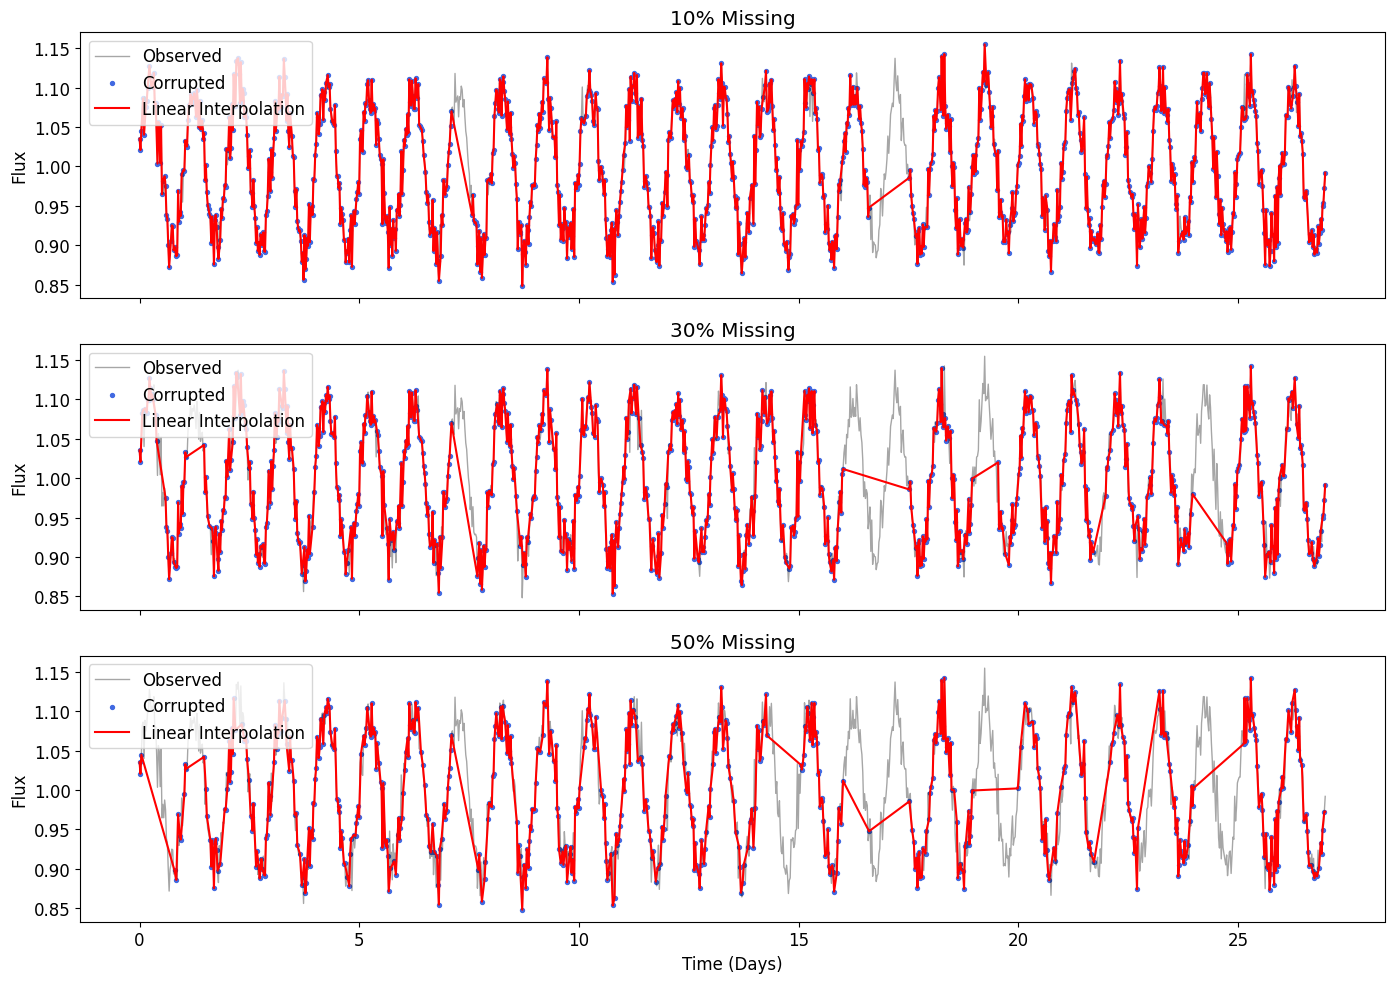

In [13]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True
)

for ax, (level, df) in zip(axes, results.items()):

    ax.plot(
        df["time"],
        df["observed_flux"],
        color="black",
        linewidth=1,
        alpha=0.35,
        label="Observed"
    )

    ax.scatter(
        df["time"],
        df["corrupted_flux"],
        s=8,
        color="royalblue",
        label="Corrupted"
    )

    ax.plot(
        df["time"],
        df["imputed_flux"],
        color="red",
        linewidth=1.5,
        label="Linear Interpolation"
    )

    ax.set_title(f"{level}% Missing")

    ax.set_ylabel("Flux")

    ax.legend()

plt.xlabel("Time (Days)")

plt.tight_layout()

plt.show()

- ## Plot Only the Imputed Values

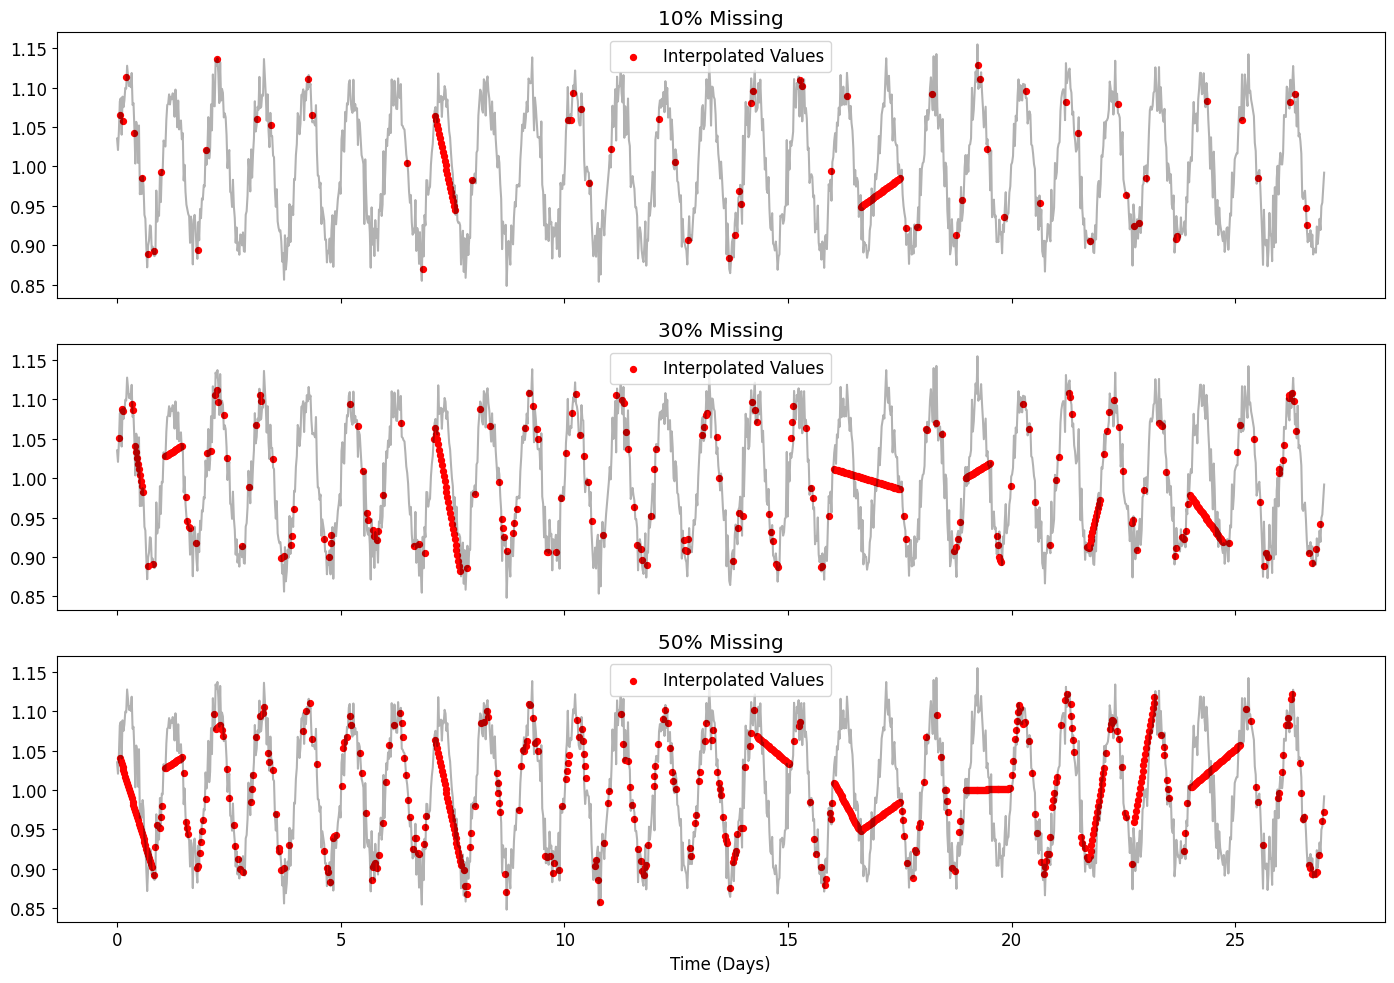

In [14]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True
)

for ax, (level, df) in zip(axes, results.items()):

    missing = df["mask"] == 0

    ax.plot(
        df["time"],
        df["observed_flux"],
        color="black",
        alpha=0.30
    )

    ax.scatter(
        df.loc[missing, "time"],
        df.loc[missing, "imputed_flux"],
        color="red",
        s=18,
        label="Interpolated Values"
    )

    ax.set_title(f"{level}% Missing")

    ax.legend()

plt.xlabel("Time (Days)")

plt.tight_layout()

plt.show()

- ## Summary Statistics

In [15]:
statistics = []

for level, df in results.items():

    statistics.append({

        "Dataset": f"{level}%",

        "Mean":
        df["imputed_flux"].mean(),

        "Median":
        df["imputed_flux"].median(),

        "Std":
        df["imputed_flux"].std(),

        "Minimum":
        df["imputed_flux"].min(),

        "Maximum":
        df["imputed_flux"].max()

    })

statistics = pd.DataFrame(statistics)

statistics

,Dataset,Mean,Median,Std,Minimum,Maximum
0,10%,0.997364,0.992128,0.072000,0.848224,1.154864
1,30%,0.993965,0.992924,0.068738,0.853494,1.142268
2,50%,0.997797,1.000508,0.065888,0.848224,1.142584


- ## Save the Imputed Datasets

In [16]:
OUTPUT_DIR = Path(
    "data/imputed_data/linear_interpolation"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for level, df in results.items():

    filename = OUTPUT_DIR / f"linear_interpolation_{level}.csv"

    df.to_csv(
        filename,
        index=False
    )

    print(f"Saved: {filename}")

Saved: data/imputed_data/linear_interpolation/linear_interpolation_10.csv
Saved: data/imputed_data/linear_interpolation/linear_interpolation_30.csv
Saved: data/imputed_data/linear_interpolation/linear_interpolation_50.csv


- ## Quick Verification

In [17]:
for level, df in results.items():

    print("=" * 60)

    print(f"Gap {level}%")

    print(df[[
        "time",
        "corrupted_flux",
        "imputed_flux"
    ]].head(10))

Gap 10%
     time  corrupted_flux  imputed_flux
0  0.0000        1.035281      1.035281
1  0.0204        1.020786      1.020786
2  0.0408        1.044930      1.044930
3  0.0612             NaN      1.065668
4  0.0816        1.086405      1.086405
5  0.1020        1.040245      1.040245
6  0.1224             NaN      1.057689
7  0.1428        1.075134      1.075134
8  0.1632        1.083429      1.083429
9  0.1836        1.099635      1.099635
Gap 30%
     time  corrupted_flux  imputed_flux
0  0.0000        1.035281      1.035281
1  0.0204        1.020786      1.020786
2  0.0408             NaN      1.051558
3  0.0612        1.082330      1.082330
4  0.0816        1.086405      1.086405
5  0.1020             NaN      1.087476
6  0.1224        1.088548      1.088548
7  0.1428             NaN      1.085988
8  0.1632        1.083429      1.083429
9  0.1836        1.099635      1.099635
Gap 50%
     time  corrupted_flux  imputed_flux
0  0.0000        1.035281      1.035281
1  0.0204       